In [1]:
%pip install scikit-learn
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


#### O que é KMeans?
- O K-Means é um algoritmo de aprendizado não supervisionado, usado para clustering (agrupamento). Ele é útil quando temos dados sem rótulos (labels), e queremos descobrir grupos naturais dentro desses dados.
- Ideia Central:
  - Assumimos que que existem k clusters (grupos) nos dados.
  - Cada grupo é representado por um centróide (média dos pontos do grupo).
  - A ideia é que os pontos que pertencem ao mesmo cluster estejam próximos no espaço (medido por distância Euclidiana L2).

#### Como funciona?
- Etapas principais:
  - 1) Inicialização:
    - Escolher k centróides iniciais aleatoriamente.
  - 2) Atribuição:
    - Cada ponto é atribuido ao centróide mais próximo.
  - 3) Atualização:
    - Recalcular os centróides como a média dos pontos atribuídos a ele.
  - 4) Repetição:
    - Repetir os passos 2 e 3 até os centróides não mudarem mais significativamente (utilizar uma tolerância) ou atingir um número máximo de iterações.



In [3]:
import numpy as np
from typing import Optional
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt

In [4]:
class KMeansCustom:
    def __init__(
        self,
        n_clusters: int = 8,
        max_iter: int = 300,
        tol: float = 1e-4,
        random_state: Optional[int] = None
    ):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.rng = np.random.default_rng(random_state)
    
    def _init_centroids(
        self,
        X: np.ndarray
    ) -> np.ndarray:
        n_samples, _ = X.shape
        idx = self.rng.choice(n_samples, self.n_clusters, replace=False)
        return X[idx]

    def fit(self, X: np.ndarray):
        centers = self._init_centroids(X)
        
        for _ in range(self.max_iter):
            d2 = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
            labels = d2.argmin(axis=1)
            
            new_centers = np.empty_like(centers)
            for k in range(self.n_clusters):
                mask = labels == k
                if not np.any(mask):
                    new_centers[k] = X[self.rng.integers(0, X.shape[0])]
                else:
                    new_centers[k] = X[mask].mean(axis=0)
                
            shift = np.linalg.norm(new_centers - centers)
            centers = new_centers
            if shift <= self.tol:
                break
            
        self.cluster_centers_ = centers
        self.labels_ = labels
        return self

In [5]:
iris = load_iris()

features = iris.feature_names

print(features)

X = iris.data[:, [2, 3]]

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
kmeans = KMeansCustom(n_clusters=3, random_state=314)
kmeans.fit(X_scaled)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

In [9]:
sil = silhouette_score(X_scaled, labels)
ari = adjusted_rand_score(iris.target, labels)
print(f"silhouette = {sil:.3f} | ARI = {ari:.3f}")

silhouette = 0.674 | ARI = 0.886


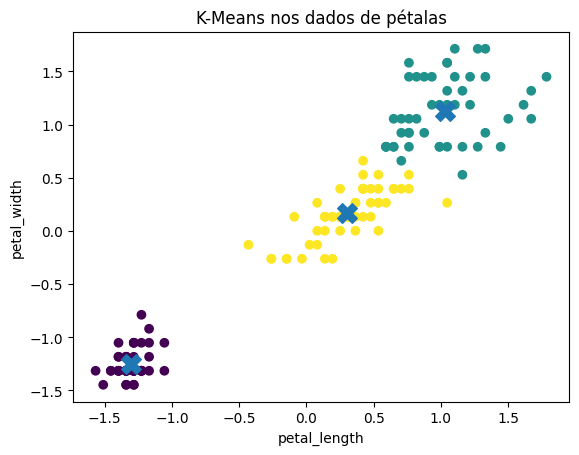

In [10]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels)
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200)
plt.title('K-Means nos dados de pétalas')
plt.xlabel('petal_length')
plt.ylabel('petal_width')
plt.show()

In [11]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt

In [12]:
wine = load_wine()

features = wine.feature_names

print(features)

X = wine.data[:, [6, 0]]

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
kmeans = KMeansCustom(n_clusters=3, random_state=314)
kmeans.fit(X_scaled)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

In [16]:
sil = silhouette_score(X_scaled, labels)
ari = adjusted_rand_score(wine.target, labels)
print(f"silhouette = {sil:.3f} | ARI = {ari:.3f}")

silhouette = 0.499 | ARI = 0.734


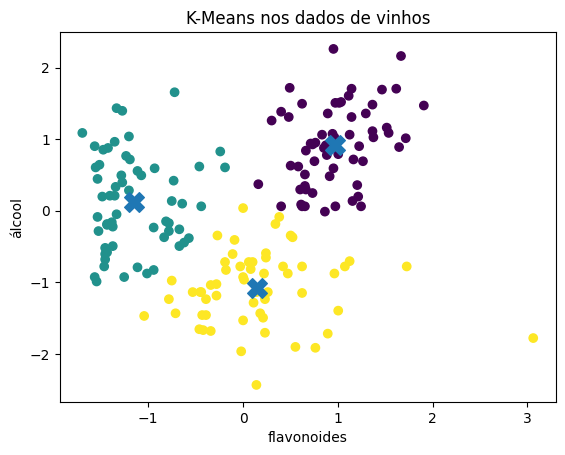

In [17]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels)
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200)
plt.title('K-Means nos dados de vinhos')
plt.xlabel('flavonoides')
plt.ylabel('álcool')
plt.show()